In [1]:
import numpy as np
import pandas as pd
from astropy.time import Time
from datetime import timezone

import bokeh
from bokeh.io import push_notebook, show, output_notebook
from bokeh.plotting import figure

import matplotlib as mpl
import matplotlib.pyplot as plt

output_notebook()

Loading BokehJS ...

In [2]:
clouds = pd.read_hdf('clouds.h5', 'clouds')
clouds.head()

year  month  sday  eday  clouds source  simulated
date       quarter                                                   
1975-01-01 1        1975      1     1     2       0   ctio      False
           2        1975      1     1     2       0   ctio      False
           3        1975      1     1     2       0   ctio      False
           4        1975      1     1     2       0   ctio      False
1975-01-02 1        1975      1     2     3       0   ctio      False

In [3]:
clouds.reset_index().describe(include='all')

,date,quarter,year,month,sday,eday,clouds,source,simulated
count,69652,69652.000000,69652.000000,69652.000000,69652.000000,69652.000000,69652.000000,69652,69652
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ctio,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55995,66700
mean,1998-11-02 13:53:59.855280512,2.500000,1998.340608,6.495894,15.725952,15.726067,1.747200,NaN,NaN
min,1975-01-01 00:00:00,1.000000,1975.000000,1.000000,1.000000,1.000000,0.000000,NaN,NaN
25%,1986-12-02 00:00:00,1.750000,1986.000000,4.000000,8.000000,8.000000,0.000000,NaN,NaN
50%,1998-11-03 00:00:00,2.500000,1998.000000,7.000000,16.000000,16.000000,0.000000,NaN,NaN
75%,2010-10-04 00:00:00,3.250000,2010.000000,9.000000,23.000000,23.000000,3.000000,NaN,NaN
max,2022-09-04 00:00:00,4.000000,2022.000000,12.000000,31.000000,31.000000,8.000000,NaN,NaN


In [4]:
counts_by_source = clouds.groupby('source').agg({'clouds': 'count'}).rename(columns={'clouds': 'counts'})
counts_by_source['fraction'] = (counts_by_source.counts/len(clouds)).round(3)
counts_by_source

,counts,fraction
source,,
blanco,10537,0.151
ctio,55995,0.804
satellite,168,0.002
stochastic_matrix,2952,0.042


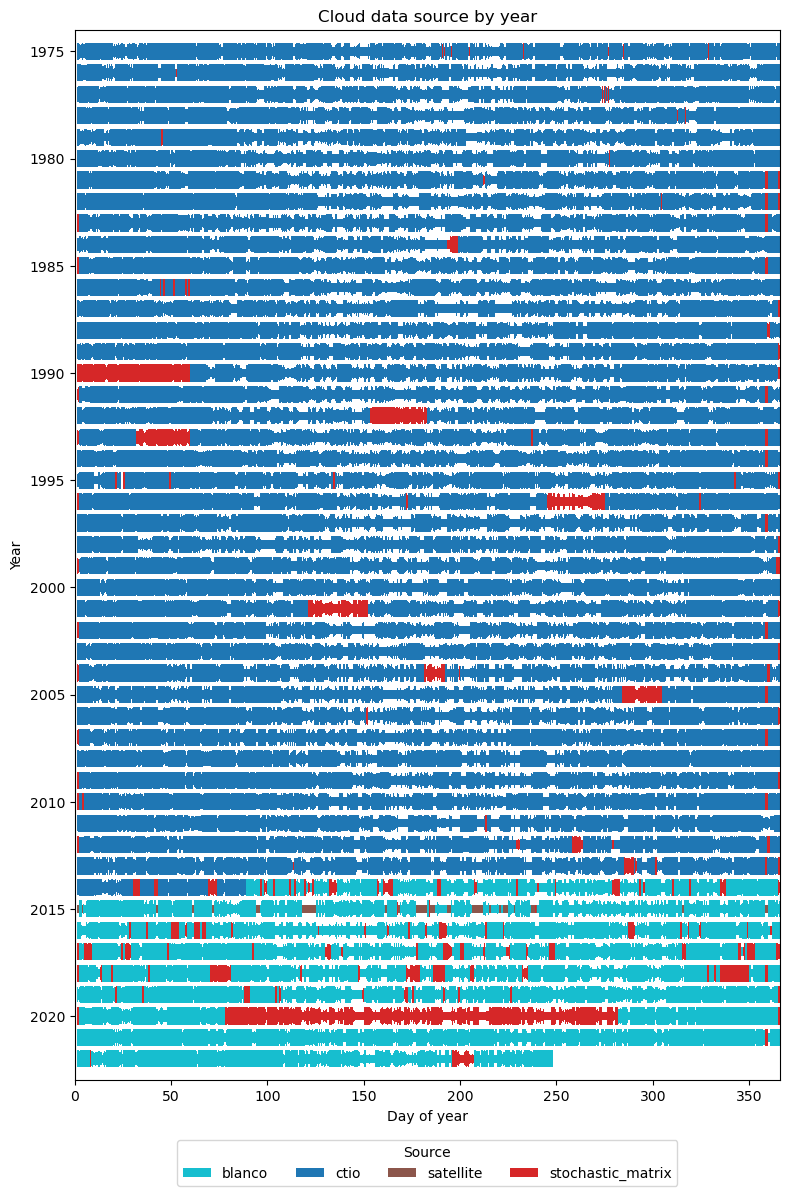

In [10]:
df = clouds.reset_index()
df['doy'] = df['date'].dt.dayofyear + (df['quarter'] - 1) * 0.25
df = df.sort_values(['year', 'doy'])

# Identify contiguous runs of the same source and cloud value within each year
df['run_id'] = (
    (df['source'] != df['source'].shift())
    | (df['year'] != df['year'].shift())
    | (df['clouds'] != df['clouds'].shift())
).cumsum()

runs = df.groupby('run_id').agg(
    year=('year', 'first'),
    source=('source', 'first'),
    clouds=('clouds', 'first'),
    start=('doy', 'min'),
    end=('doy', 'max'),
)
runs['width'] = runs['end'] - runs['start'] + 0.25
runs['alpha'] = 1.0 # - (runs['clouds'] / 8.0) * 0.5
max_bar_height = 0.8
runs['bar_height'] = max_bar_height * (1.0 - 0.5 * runs['clouds'] / 8.0)

source_color_index = {
    'ctio': 0,
    'blanco': 9,
    'satellite': 5,
    'stochastic_matrix': 3,
}
sources = sorted(df['source'].unique())
cmap = plt.get_cmap('tab10')
years = np.sort(df['year'].unique())

fig, ax = plt.subplots(figsize=(8, 0.25 * len(years)))

for source in sources:
    mask = runs['source'] == source
    subset = runs[mask]
    color = cmap(source_color_index[source])
    labeled = False
    # Group by (alpha, bar_height) to reduce the number of draw calls
    for (alpha, bh), grp in subset.groupby(['alpha', 'bar_height']):
        ax.barh(
            grp['year'], grp['width'], left=grp['start'],
            height=bh, color=color, alpha=alpha,
            label=source if not labeled else None,
        )
        labeled = True

ax.set_yticks(years[::5])
ax.set_xlabel('Day of year')
ax.set_ylabel('Year')
ax.set_title('Cloud data source by year')
ax.legend(title='Source', loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=len(sources))
ax.set_ylim(clouds.year.min()-1, clouds.year.max()+1)
ax.invert_yaxis()
ax.set_xlim(0, 366)

plt.tight_layout()
plt.show()
